<a href="https://colab.research.google.com/github/VitorBZS/Avaliacao-02-AAPL-Apple-Volatilidade/blob/main/C%C3%B3pia_de_prova_02_vitor_bonilha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02: AAPL (APPLE) | Volatilidade:
Alvo ($Y$): Alta_Volatilidade se (high - low) superar a média histórica de 100 dias.

Desafio: Normalizar rigorosamente a amplitude e gerar seu histograma.

## Aluno: Vitor Hugo Bonilha Zanatta Silva

#1. Extração

##Configurações

In [ ]:
import pandas as pd
import requests
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
API_KEY = "0XRTPWUZLEA2ZAG0"
SYMBOL = "AAPL"
url = f"https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol={SYMBOL}&outputsize=compact&apikey={API_KEY}"

##Extração e Conversão Inicial

In [ ]:
response = requests.get(url)
data = response.json()

df = pd.DataFrame.from_dict(data["Time Series (Daily)"], orient = "index")
df.columns = ["open", "high", "low", "close", "volume"]
df = df.astype(float)
df.index = pd.to_datetime(df.index)
df.sort_index(ascending = True, inplace = True)

df.head()

,open,high,low,close,volume
2026-01-22,249.20,251.000,248.15,248.35,39708340.0
2026-01-23,247.32,249.410,244.68,248.04,41688982.0
2026-01-26,251.48,256.560,249.80,255.41,55969234.0
2026-01-27,259.17,261.950,258.21,258.27,48787855.0
2026-01-28,257.65,258.855,254.51,256.44,41287971.0


#2. Tratamento e Normalização

## Verificação de Nulos

In [ ]:
print(df.isnull().sum())

open      0
high      0
low       0
close     0
volume    0
dtype: int64


## Engenharia de Preditores (X)

In [ ]:
df['amplitude_raw'] = df['high'] - df['low']
df['X_amplitude'] = df['amplitude_raw'].shift(1)
df['X_volume'] = df['volume'].shift(1)
df_clean = df.dropna().copy()

## Aplicação do StandardScaler

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[['X_amplitude', 'X_volume']])

## DataFrame de Preditores (X)

In [ ]:
X = pd.DataFrame(X_scaled, columns = ['amplitude_norm', 'volume_norm'], index = df_clean.index)

#3. Visualização

## Gráfico de Fechamento

Text(0.5, 1.0, 'Fechamento AAPL')

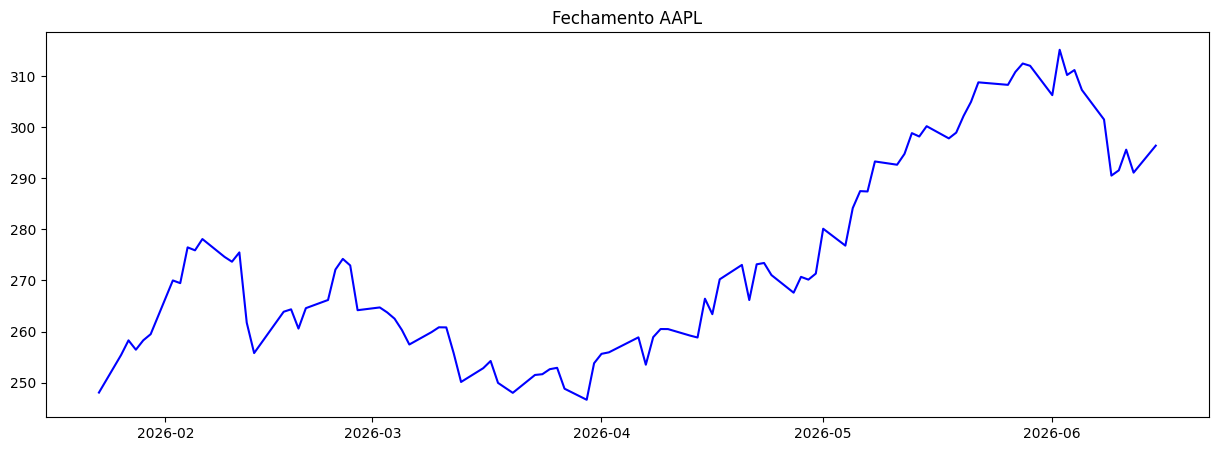

In [ ]:
plt.figure(figsize = (15, 5))

plt.plot(df_clean['close'], color= 'blue')
plt.title('Fechamento AAPL')

## Gráfico de Volume

Text(0.5, 1.0, 'Volume Diário')

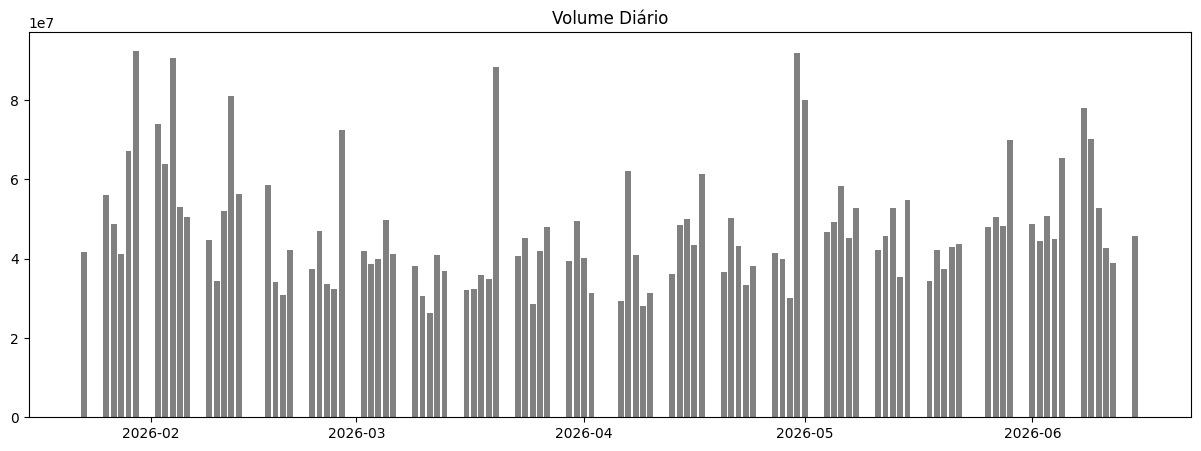

In [ ]:
plt.figure(figsize = (15, 5))

plt.bar(df_clean.index, df_clean['volume'], color= 'gray')
plt.title('Volume Diário')

## DESAFIO: Histograma da Amplitude Normalizada

Text(0.5, 1.0, 'Histograma: Amplitude Normalizada')

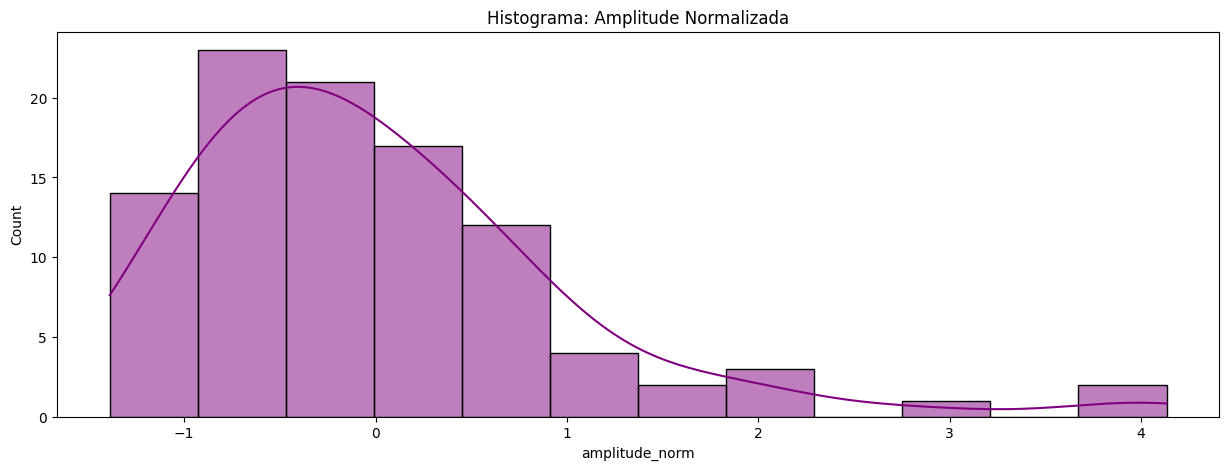

In [ ]:
plt.figure(figsize = (15, 5))


sns.histplot(X['amplitude_norm'], kde = True, color = 'purple')
plt.title('Histograma: Amplitude Normalizada')

#4. Laborização (Feature Engineering)

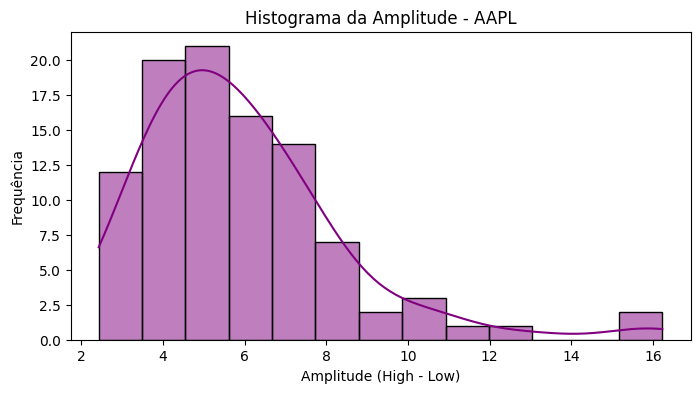

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Criando as colunas no DataFrame original (df)
df['amplitude_raw'] = df['high'] - df['low']

# min_periods=1 permite calcular a média com os dados disponíveis no modo compact
df['media_100'] = df['amplitude_raw'].rolling(window=100, min_periods=1).mean()

# 2. Criação do Alvo (Y) segundo a regra da prova
df['Y'] = (df['amplitude_raw'] > df['media_100']).astype(int)

# 3. Criação dos preditores (X) defasados em 1 dia para evitar Data Leakage
df['X_amplitude'] = df['amplitude_raw'].shift(1)
df['X_volume'] = df['volume'].shift(1)

# 4. AGORA SIM criamos o df_clean, removendo a primeira linha (que fica nula pelo shift)
df_clean = df.dropna().copy()

# 5. DESAFIO: Histograma da amplitude solicitado no enunciado
plt.figure(figsize=(8, 4))
sns.histplot(df_clean['amplitude_raw'], kde=True, color='purple')
plt.title('Histograma da Amplitude - AAPL')
plt.xlabel('Amplitude (High - Low)')
plt.ylabel('Frequência')
plt.show()

#5. Ingestão Bayesiana

Acurácia Corrigida do Modelo: 65.00%

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.56      1.00      0.72         9
           1       1.00      0.36      0.53        11

    accuracy                           0.65        20
   macro avg       0.78      0.68      0.63        20
weighted avg       0.80      0.65      0.62        20



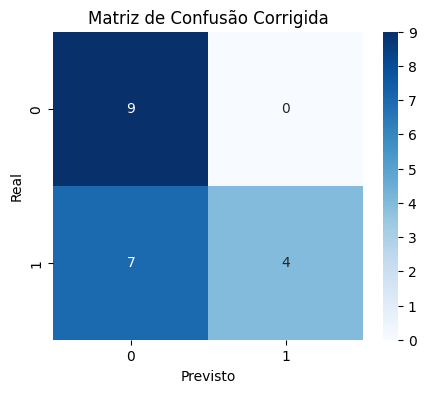

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Seleção das colunas preditoras corretas (X) e do alvo (Y)
X_dados = df_clean[['X_amplitude', 'X_volume']]
y_dados = df_clean['Y']

# 2. Divisão em Treino e Teste (shuffle=False mantém a ordem cronológica correta para finanças)
X_train, X_test, y_train, y_test = train_test_split(
    X_dados, y_dados, test_size=0.2, random_state=42, shuffle=False
)

# 3. NORMALIZAÇÃO RIGOROSA (Sem Data Leakage)
scaler = StandardScaler()
# O fit_transform calcula a média/desvio APENAS do Treino e aplica a escala nele
X_train_scaled = scaler.fit_transform(X_train)
# O transform APENAS aplica a escala no Teste usando o que foi aprendido no Treino
X_test_scaled = scaler.transform(X_test)

# 4. Treinamento do GaussianNB
model = GaussianNB()
model.fit(X_train_scaled, y_train)

# 5. Avaliação dos Resultados
y_pred = model.predict(X_test_scaled)

print(f"Acurácia Corrigida do Modelo: {accuracy_score(y_test, y_pred):.2%}\n")
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred))

# Matriz de Confusão para enriquecer a entrega da prova
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão Corrigida')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.show()